# NumPy & Matplotlib Fundamentals

A practical walkthrough of the two libraries you'll use in almost every Python data/science project.

- **NumPy** — fast numerical arrays and math operations
- **Matplotlib** — plotting and visualization


---
## Part 1: NumPy


### 1.1 Creating Arrays

`np.array()` converts a Python list into a NumPy array. The difference: Python lists are general-purpose containers,
NumPy arrays are fixed-type, contiguous blocks of memory optimized for math. Operations on NumPy arrays are 10–100x
faster than equivalent Python loops.


In [1]:
import numpy as np

# From a Python list
a = np.array([1, 2, 3, 4, 5])
print("Array:", a)
print("Type:", type(a))
print("Dtype:", a.dtype)  # int64 — NumPy inferred the data type from the values


Array: [1 2 3 4 5]
Type: <class 'numpy.ndarray'>
Dtype: int64


### 1.2 Array Generators

NumPy provides functions to create common arrays without manually typing values.

| Function | What it generates |
|---|---|
| `np.zeros(n)` | Array of `n` zeros |
| `np.ones(n)` | Array of `n` ones |
| `np.arange(start, stop, step)` | Evenly spaced values (like Python's `range`, but returns an array) |
| `np.linspace(start, stop, n)` | Exactly `n` values evenly spaced between `start` and `stop` (inclusive) |

`arange` vs `linspace`: use `arange` when you know the **step size**, use `linspace` when you know the **number of
points** you want.


In [2]:
print("Zeros:", np.zeros(5))
print("Ones:", np.ones(4))
print("Arange:", np.arange(0, 10, 2))       # [0, 2, 4, 6, 8] — stop is excluded
print("Linspace:", np.linspace(0, 1, 5))     # [0, 0.25, 0.5, 0.75, 1.0] — stop is included


Zeros: [0. 0. 0. 0. 0.]
Ones: [1. 1. 1. 1.]
Arange: [0 2 4 6 8]
Linspace: [0.   0.25 0.5  0.75 1.  ]


### 1.3 Shape and Dimensions

Every array has a `.shape` — a tuple describing its size along each axis.

- 1D array of 5 elements → shape `(5,)`
- 2D array with 3 rows and 4 columns → shape `(3, 4)`
- `.ndim` — number of dimensions
- `.size` — total number of elements


In [3]:
# 1D
a = np.array([10, 20, 30])
print("Shape:", a.shape)    # (3,)
print("Ndim:", a.ndim)      # 1

# 2D — a list of lists becomes a matrix
matrix = np.array([
    [1, 2, 3],
    [4, 5, 6]
])
print("Shape:", matrix.shape)   # (2, 3) → 2 rows, 3 columns
print("Ndim:", matrix.ndim)     # 2
print("Size:", matrix.size)     # 6


Shape: (3,)
Ndim: 1
Shape: (2, 3)
Ndim: 2
Size: 6


### 1.4 Indexing and Slicing

Works like Python lists, but extended to multiple dimensions.

- `a[i]` — element at index `i` (0-based)
- `a[start:stop]` — slice from `start` up to (not including) `stop`
- For 2D: `matrix[row, col]` or `matrix[row_slice, col_slice]`


In [4]:
a = np.array([10, 20, 30, 40, 50])

print(a[0])       # 10 — first element
print(a[-1])      # 50 — last element
print(a[1:4])     # [20, 30, 40] — slice

# 2D indexing
matrix = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

print(matrix[0, 2])     # 3 — row 0, column 2
print(matrix[:, 1])     # [2, 5, 8] — all rows, column 1
print(matrix[1, :])     # [4, 5, 6] — row 1, all columns


10
50
[20 30 40]
3
[2 5 8]
[4 5 6]


### 1.5 Reshape and Transpose

- `.reshape(new_shape)` — rearranges elements into a new shape without changing the data. Total element count must
stay the same.
- `.T` — transposes the array (swaps rows and columns). This is what we used in the VEP notebook to convert
`(samples, channels)` → `(channels, samples)` for MNE.


In [5]:
a = np.arange(12)  # [0, 1, 2, ..., 11]
print("Original shape:", a.shape)  # (12,)

reshaped = a.reshape(3, 4)  # 3 rows × 4 columns = 12 elements
print("Reshaped:\n", reshaped)

transposed = reshaped.T  # swap rows ↔ columns → becomes (4, 3)
print("Transposed shape:", transposed.shape)
print("Transposed:\n", transposed)


Original shape: (12,)
Reshaped:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Transposed shape: (4, 3)
Transposed:
 [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]


### 1.6 Element-wise Operations

Unlike Python lists, NumPy arrays apply math operations **element by element** automatically. No loops needed.

This is called **vectorization** — it's the main reason NumPy is fast.


In [6]:
a = np.array([1, 2, 3, 4])
b = np.array([10, 20, 30, 40])

print("Add:", a + b)         # [11, 22, 33, 44]
print("Multiply:", a * b)    # [10, 40, 90, 160]
print("Scalar:", a * 100)    # [100, 200, 300, 400] — broadcasts the scalar to every element
print("Square:", a ** 2)     # [1, 4, 9, 16]


Add: [11 22 33 44]
Multiply: [ 10  40  90 160]
Scalar: [100 200 300 400]
Square: [ 1  4  9 16]


### 1.7 Aggregation Functions

These reduce an array down to a single summary value (or along a specific axis).

| Function | Returns |
|---|---|
| `np.sum(a)` | Total sum |
| `np.mean(a)` | Arithmetic mean |
| `np.std(a)` | Standard deviation |
| `np.min(a)`, `np.max(a)` | Minimum / maximum value |
| `np.argmin(a)`, `np.argmax(a)` | *Index* of the min / max value |

For 2D arrays, pass `axis=0` to aggregate along rows (column-wise) or `axis=1` to aggregate along columns (row-
wise).


In [7]:
data = np.array([
    [10, 20, 30],
    [40, 50, 60]
])

print("Overall mean:", np.mean(data))          # 35.0
print("Mean per column:", np.mean(data, axis=0))  # [25, 35, 45] — averages down each column
print("Mean per row:", np.mean(data, axis=1))     # [20, 50] — averages across each row
print("Max value:", np.max(data))                  # 60
print("Index of max:", np.argmax(data))            # 5 (flat index)


Overall mean: 35.0
Mean per column: [25. 35. 45.]
Mean per row: [20. 50.]
Max value: 60
Index of max: 5


### 1.8 Boolean Indexing (Filtering)

You can use a condition to create a boolean mask and then use it to select elements. This replaces the need for loops
and `if` statements when filtering data.


In [8]:
values = np.array([3, -1, 7, -5, 2, 8, -3])

# The condition creates a boolean array
mask = values > 0
print("Mask:", mask)            # [True, False, True, False, True, True, False]

# Use the mask to filter
positive_only = values[mask]
print("Positive values:", positive_only)   # [3, 7, 2, 8]

# Shorthand — do it in one line
print("Greater than 5:", values[values > 5])   # [7, 8]


Mask: [ True False  True False  True  True False]
Positive values: [3 7 2 8]
Greater than 5: [7 8]


### 1.9 Random Number Generation

`np.random` provides functions to generate random arrays. Useful for simulations, testing, and adding noise.

| Function | What it generates |
|---|---|
| `np.random.rand(n)` | `n` uniform random values between 0 and 1 |
| `np.random.randn(n)` | `n` values from a standard normal distribution (mean=0, std=1) |
| `np.random.randint(low, high, size)` | Random integers in `[low, high)` |
| `np.random.seed(n)` | Sets a fixed seed so results are reproducible |


In [9]:
np.random.seed(42)  # fix the seed so output is the same every run

print("Uniform:", np.random.rand(5))
print("Normal:", np.random.randn(5))
print("Integers:", np.random.randint(0, 100, size=5))


Uniform: [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]
Normal: [ 0.27904129  1.01051528 -0.58087813 -0.52516981 -0.57138017]
Integers: [21 88 48 90 58]


### 1.10 Stacking Arrays

Combines multiple arrays into one.

- `np.column_stack()` — places arrays side by side as columns. We used this in the VEP notebook to build the 3-column
MNE events array.
- `np.vstack()` — stacks arrays vertically (row-wise).
- `np.hstack()` — stacks arrays horizontally (flattened).


In [10]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print("Column stack:\n", np.column_stack([a, b]))  # 3×2 matrix
print("Vstack:\n", np.vstack([a, b]))               # 2×3 matrix
print("Hstack:", np.hstack([a, b]))                   # [1, 2, 3, 4, 5, 6]


Column stack:
 [[1 4]
 [2 5]
 [3 6]]
Vstack:
 [[1 2 3]
 [4 5 6]]
Hstack: [1 2 3 4 5 6]


---
## Part 2: Matplotlib

`matplotlib.pyplot` (imported as `plt`) is the standard Python plotting library. Almost every plot follows the same
pattern:

1. Create a figure and axes
2. Plot data onto the axes
3. Add labels, title, legend
4. Show or save


### 2.1 Line Plot

`plt.plot(x, y)` draws a line connecting the (x, y) points in order.

- `label` — name for the legend
- `linewidth` — thickness of the line
- `alpha` — transparency (0 = invisible, 1 = solid)
- `color` — any CSS color name, hex code, or RGB tuple


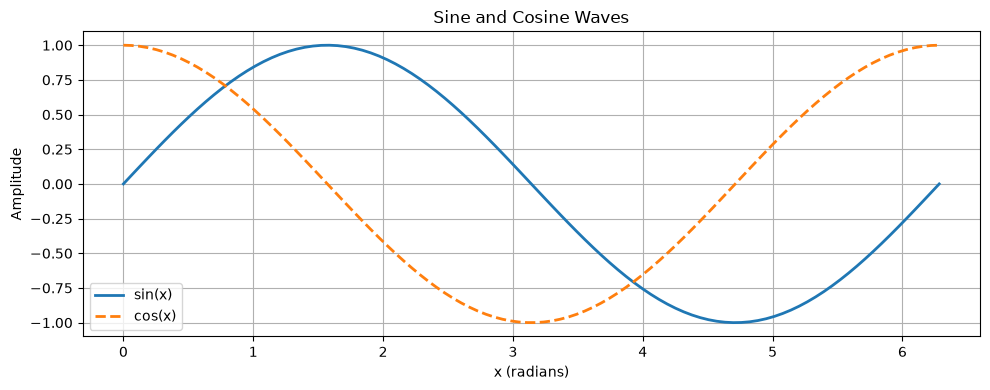

In [11]:
import matplotlib.pyplot as plt

x = np.linspace(0, 2 * np.pi, 100)  # 100 points from 0 to 2π
y_sin = np.sin(x)
y_cos = np.cos(x)

plt.figure(figsize=(10, 4))  # width=10 inches, height=4 inches
plt.plot(x, y_sin, label="sin(x)", linewidth=2)
plt.plot(x, y_cos, label="cos(x)", linewidth=2, linestyle="--")

plt.xlabel("x (radians)")
plt.ylabel("Amplitude")
plt.title("Sine and Cosine Waves")
plt.legend()       # renders the labels
plt.grid(True)     # adds a background grid
plt.tight_layout() # prevents labels from being clipped
plt.show()


### 2.2 Scatter Plot

`plt.scatter(x, y)` draws individual points without connecting them. Useful for showing relationships between two
variables.

- `s` — marker size
- `c` — color (can be a single color or an array of values for a colormap)
- `cmap` — colormap name (e.g. `'viridis'`, `'coolwarm'`)


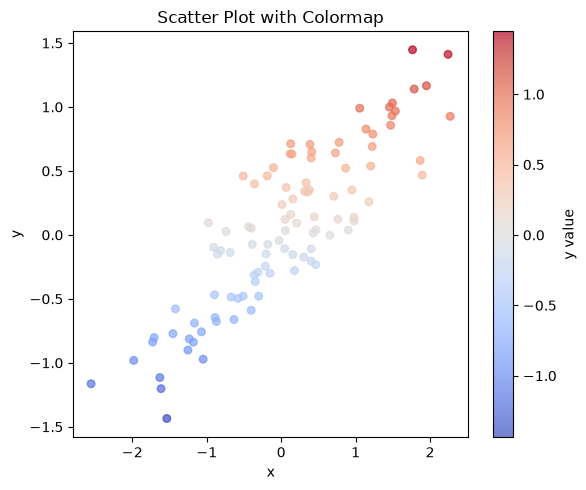

In [12]:
np.random.seed(0)
x = np.random.randn(100)
y = x * 0.5 + np.random.randn(100) * 0.3  # correlated with noise

plt.figure(figsize=(6, 5))
plt.scatter(x, y, s=30, alpha=0.7, c=y, cmap='coolwarm')
plt.colorbar(label="y value")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Plot with Colormap")
plt.tight_layout()
plt.show()


### 2.3 Bar Chart

`plt.bar(x_positions, heights)` draws vertical bars. Useful for comparing discrete categories.


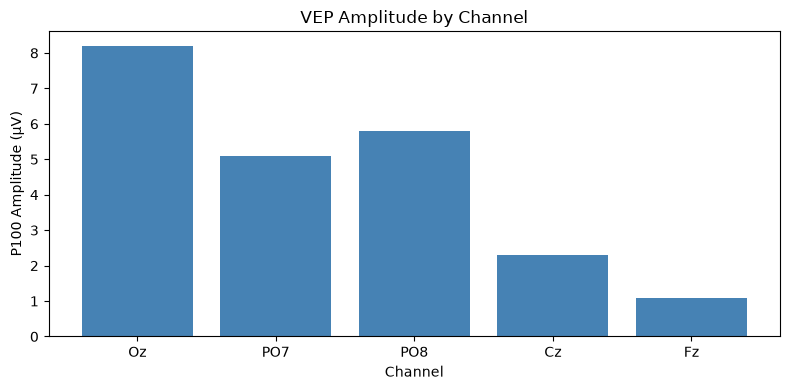

In [13]:
categories = ['Oz', 'PO7', 'PO8', 'Cz', 'Fz']
amplitudes = [8.2, 5.1, 5.8, 2.3, 1.1]

plt.figure(figsize=(8, 4))
plt.bar(categories, amplitudes, color='steelblue')
plt.xlabel("Channel")
plt.ylabel("P100 Amplitude (µV)")
plt.title("VEP Amplitude by Channel")
plt.tight_layout()
plt.show()


### 2.4 Histogram

`plt.hist(data, bins)` counts how many values fall into each bin and draws the distribution.

- `bins` — number of buckets to divide the data range into
- `edgecolor` — border color of each bar


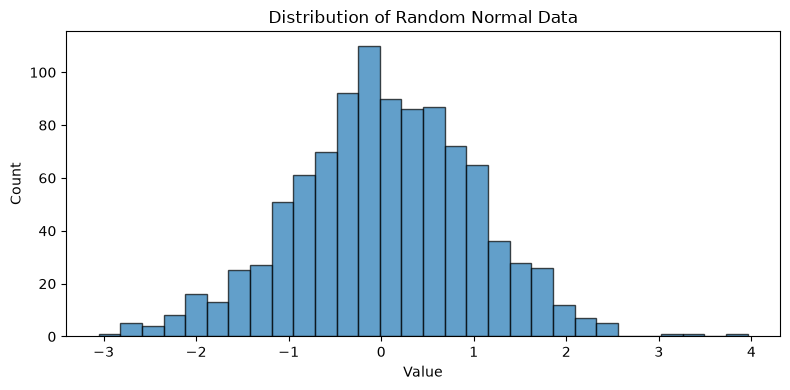

In [14]:
np.random.seed(1)
data = np.random.randn(1000)  # 1000 samples from a normal distribution

plt.figure(figsize=(8, 4))
plt.hist(data, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Distribution of Random Normal Data")
plt.tight_layout()
plt.show()


### 2.5 Subplots

`plt.subplots(rows, cols)` creates a grid of plots in one figure. Returns a `fig` (the whole canvas) and `axes`
(individual plot areas).

Each `ax` has the same methods as `plt` — `.plot()`, `.set_xlabel()`, `.set_title()`, etc.


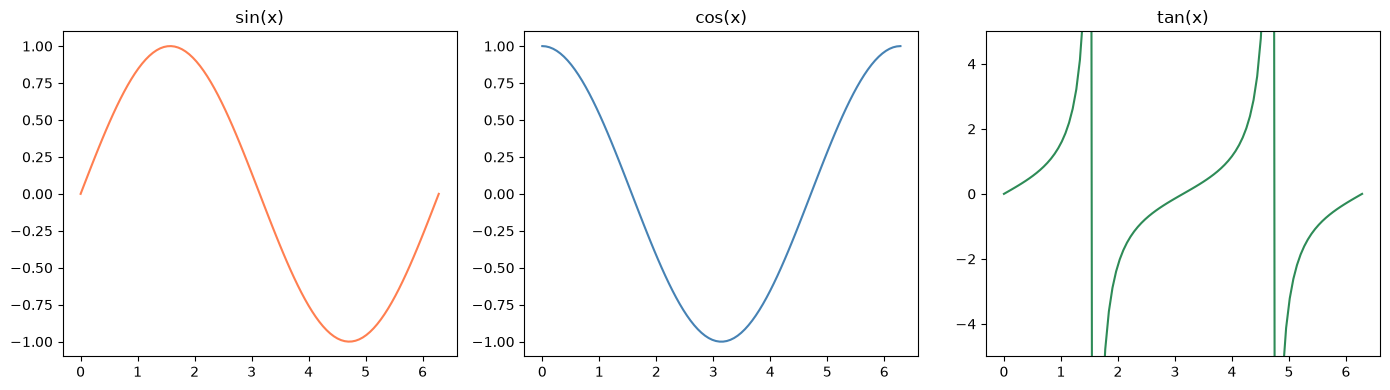

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))  # 1 row, 3 columns

x = np.linspace(0, 2 * np.pi, 100)

axes[0].plot(x, np.sin(x), color='coral')
axes[0].set_title("sin(x)")

axes[1].plot(x, np.cos(x), color='steelblue')
axes[1].set_title("cos(x)")

axes[2].plot(x, np.tan(x), color='seagreen')
axes[2].set_ylim(-5, 5)  # limit y-axis because tan() explodes at π/2
axes[2].set_title("tan(x)")

plt.tight_layout()
plt.show()


### 2.6 Vertical / Horizontal Lines

- `plt.axvline(x)` — draws a vertical line at position `x` across the full plot height
- `plt.axhline(y)` — draws a horizontal line at position `y` across the full plot width

We used `axvline` in the VEP notebook to mark stimulus event times on the EEG trace.


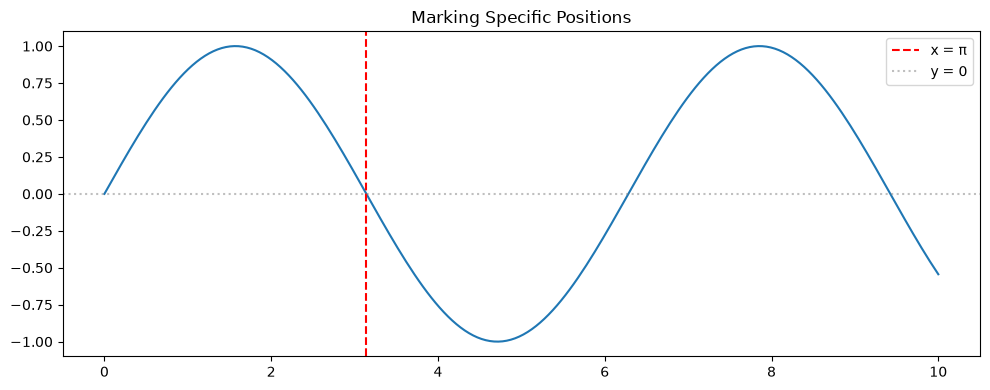

In [16]:
x = np.linspace(0, 10, 200)
y = np.sin(x)

plt.figure(figsize=(10, 4))
plt.plot(x, y)
plt.axvline(np.pi, color='red', linestyle='--', label='x = π')
plt.axhline(0, color='gray', linestyle=':', alpha=0.5, label='y = 0')
plt.legend()
plt.title("Marking Specific Positions")
plt.tight_layout()
plt.show()


### 2.7 Styling Cheat Sheet

Common parameters that work across most plot functions:

| Parameter | Example values | Effect |
|---|---|---|
| `color` | `'red'`, `'#2ecc71'`, `(0.2, 0.4, 0.8)` | Line/marker color |
| `linewidth` / `lw` | `0.5`, `2`, `3` | Line thickness |
| `linestyle` / `ls` | `'-'`, `'--'`, `':'`, `'-.'` | Solid, dashed, dotted, dash-dot |
| `alpha` | `0.0` to `1.0` | Transparency |
| `marker` | `'o'`, `'s'`, `'^'`, `'x'` | Point marker shape |
| `markersize` / `ms` | `3`, `8`, `12` | Point marker size |
| `label` | any string | Name shown in legend |


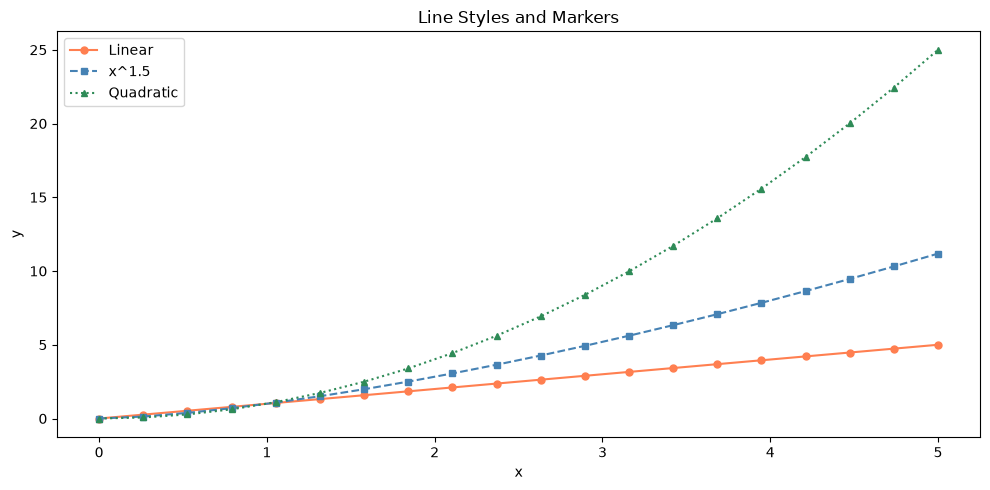

In [17]:
x = np.linspace(0, 5, 20)

plt.figure(figsize=(10, 5))
plt.plot(x, x, 'o-', label="Linear", color='coral', markersize=5)
plt.plot(x, x**1.5, 's--', label="x^1.5", color='steelblue', markersize=4)
plt.plot(x, x**2, '^:', label="Quadratic", color='seagreen', markersize=4)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Line Styles and Markers")
plt.legend()
plt.tight_layout()
plt.show()


### 2.8 Saving Figures

`plt.savefig(path)` exports the current figure to a file. The format is inferred from the file extension.

- `dpi` — resolution in dots per inch (use `150`+ for print quality)
- `bbox_inches='tight'` — crops whitespace around the plot


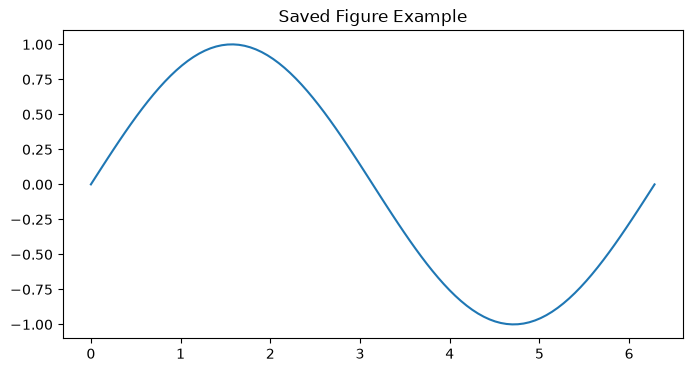

Saved to example_plot.png


In [18]:
x = np.linspace(0, 2 * np.pi, 100)

plt.figure(figsize=(8, 4))
plt.plot(x, np.sin(x))
plt.title("Saved Figure Example")
plt.savefig("example_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to example_plot.png")
